Frames loaded: 3315
Avg detections per frame — YOLO: 299.99, DETR: 30.21, WBF: 141.00


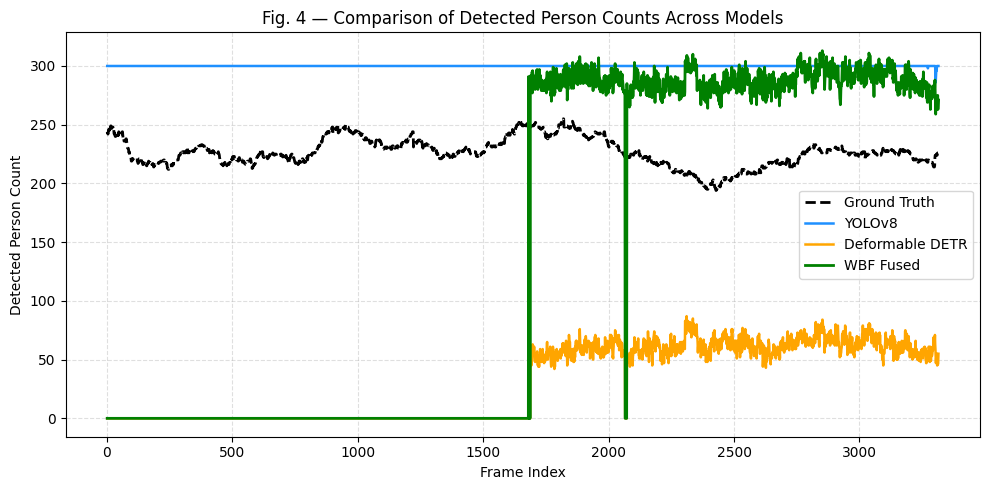

In [10]:
import matplotlib.pyplot as plt
import json, numpy as np, pandas as pd, os, re

# --- Absolute paths (no guessing, all explicit) ---
YOLO_PATH = "/content/drive/MyDrive/Store/L1model/yolo_dets"
DETR_PATH = "/content/drive/MyDrive/Store/L1model/deform_detr_dets2/MOT20-05"
WBF_PATH  = "/content/drive/MyDrive/Store/L1model/deform_detr_dets_wbf2/MOT20-05"
GT_PATH   = "/content/drive/MyDrive/Store/MOT20/train/MOT20-05/gt/gt.txt"

# --- Collect JSON files from YOLO directory ---
frame_files = sorted([f for f in os.listdir(YOLO_PATH) if f.endswith(".json")])

# Extract frame IDs robustly
def extract_id(fname):
    match = re.search(r'(\d+)', fname)
    return int(match.group(1)) if match else None

frame_ids = [extract_id(f) for f in frame_files if extract_id(f) is not None]
frame_ids.sort()

counts_yolo, counts_detr, counts_wbf, counts_gt = [], [], [], []

# --- Loop through all frame IDs ---
for fid in frame_ids:
    # YOLO detections
    yolo_file = f"{YOLO_PATH}/val_{fid:06d}.json"
    if not os.path.exists(yolo_file):
        yolo_file = f"{YOLO_PATH}/{fid:06d}.json"

    # Deformable DETR detections
    detr_file = f"{DETR_PATH}/val_{fid:06d}.json"
    if not os.path.exists(detr_file):
        detr_file = f"{DETR_PATH}/{fid:06d}.json"

    # WBF detections inside MOT20-05 folder
    wbf_file = f"{WBF_PATH}/{fid:06d}.json"

    # Load data
    yolo_dets = json.load(open(yolo_file)) if os.path.exists(yolo_file) else []
    detr_dets = json.load(open(detr_file)) if os.path.exists(detr_file) else []
    wbf_dets  = json.load(open(wbf_file)) if os.path.exists(wbf_file) else []

    counts_yolo.append(len(yolo_dets))
    counts_detr.append(len(detr_dets))
    counts_wbf.append(len(wbf_dets))

# --- Load GT person counts ---
if os.path.exists(GT_PATH):
    gt_df = pd.read_csv(GT_PATH, header=None)
    for fid in frame_ids:
        counts_gt.append(len(gt_df[gt_df[0] == fid]))
else:
    counts_gt = [np.nan] * len(frame_ids)

# --- Quick summary ---
print(f"Frames loaded: {len(frame_ids)}")
print(f"Avg detections per frame — YOLO: {np.mean(counts_yolo):.2f}, DETR: {np.mean(counts_detr):.2f}, WBF: {np.mean(counts_wbf):.2f}")

# --- Plot comparison ---
plt.figure(figsize=(10,5))
plt.plot(frame_ids, counts_gt,  '--', color='black', label='Ground Truth', linewidth=2)
plt.plot(frame_ids, counts_yolo, color='dodgerblue', label='YOLOv8', linewidth=1.8)
plt.plot(frame_ids, counts_detr, color='orange', label='Deformable DETR', linewidth=1.8)
plt.plot(frame_ids, counts_wbf,  color='green', label='WBF Fused', linewidth=2)

plt.xlabel("Frame Index")
plt.ylabel("Detected Person Count")
plt.title("Fig. 4 — Comparison of Detected Person Counts Across Models")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


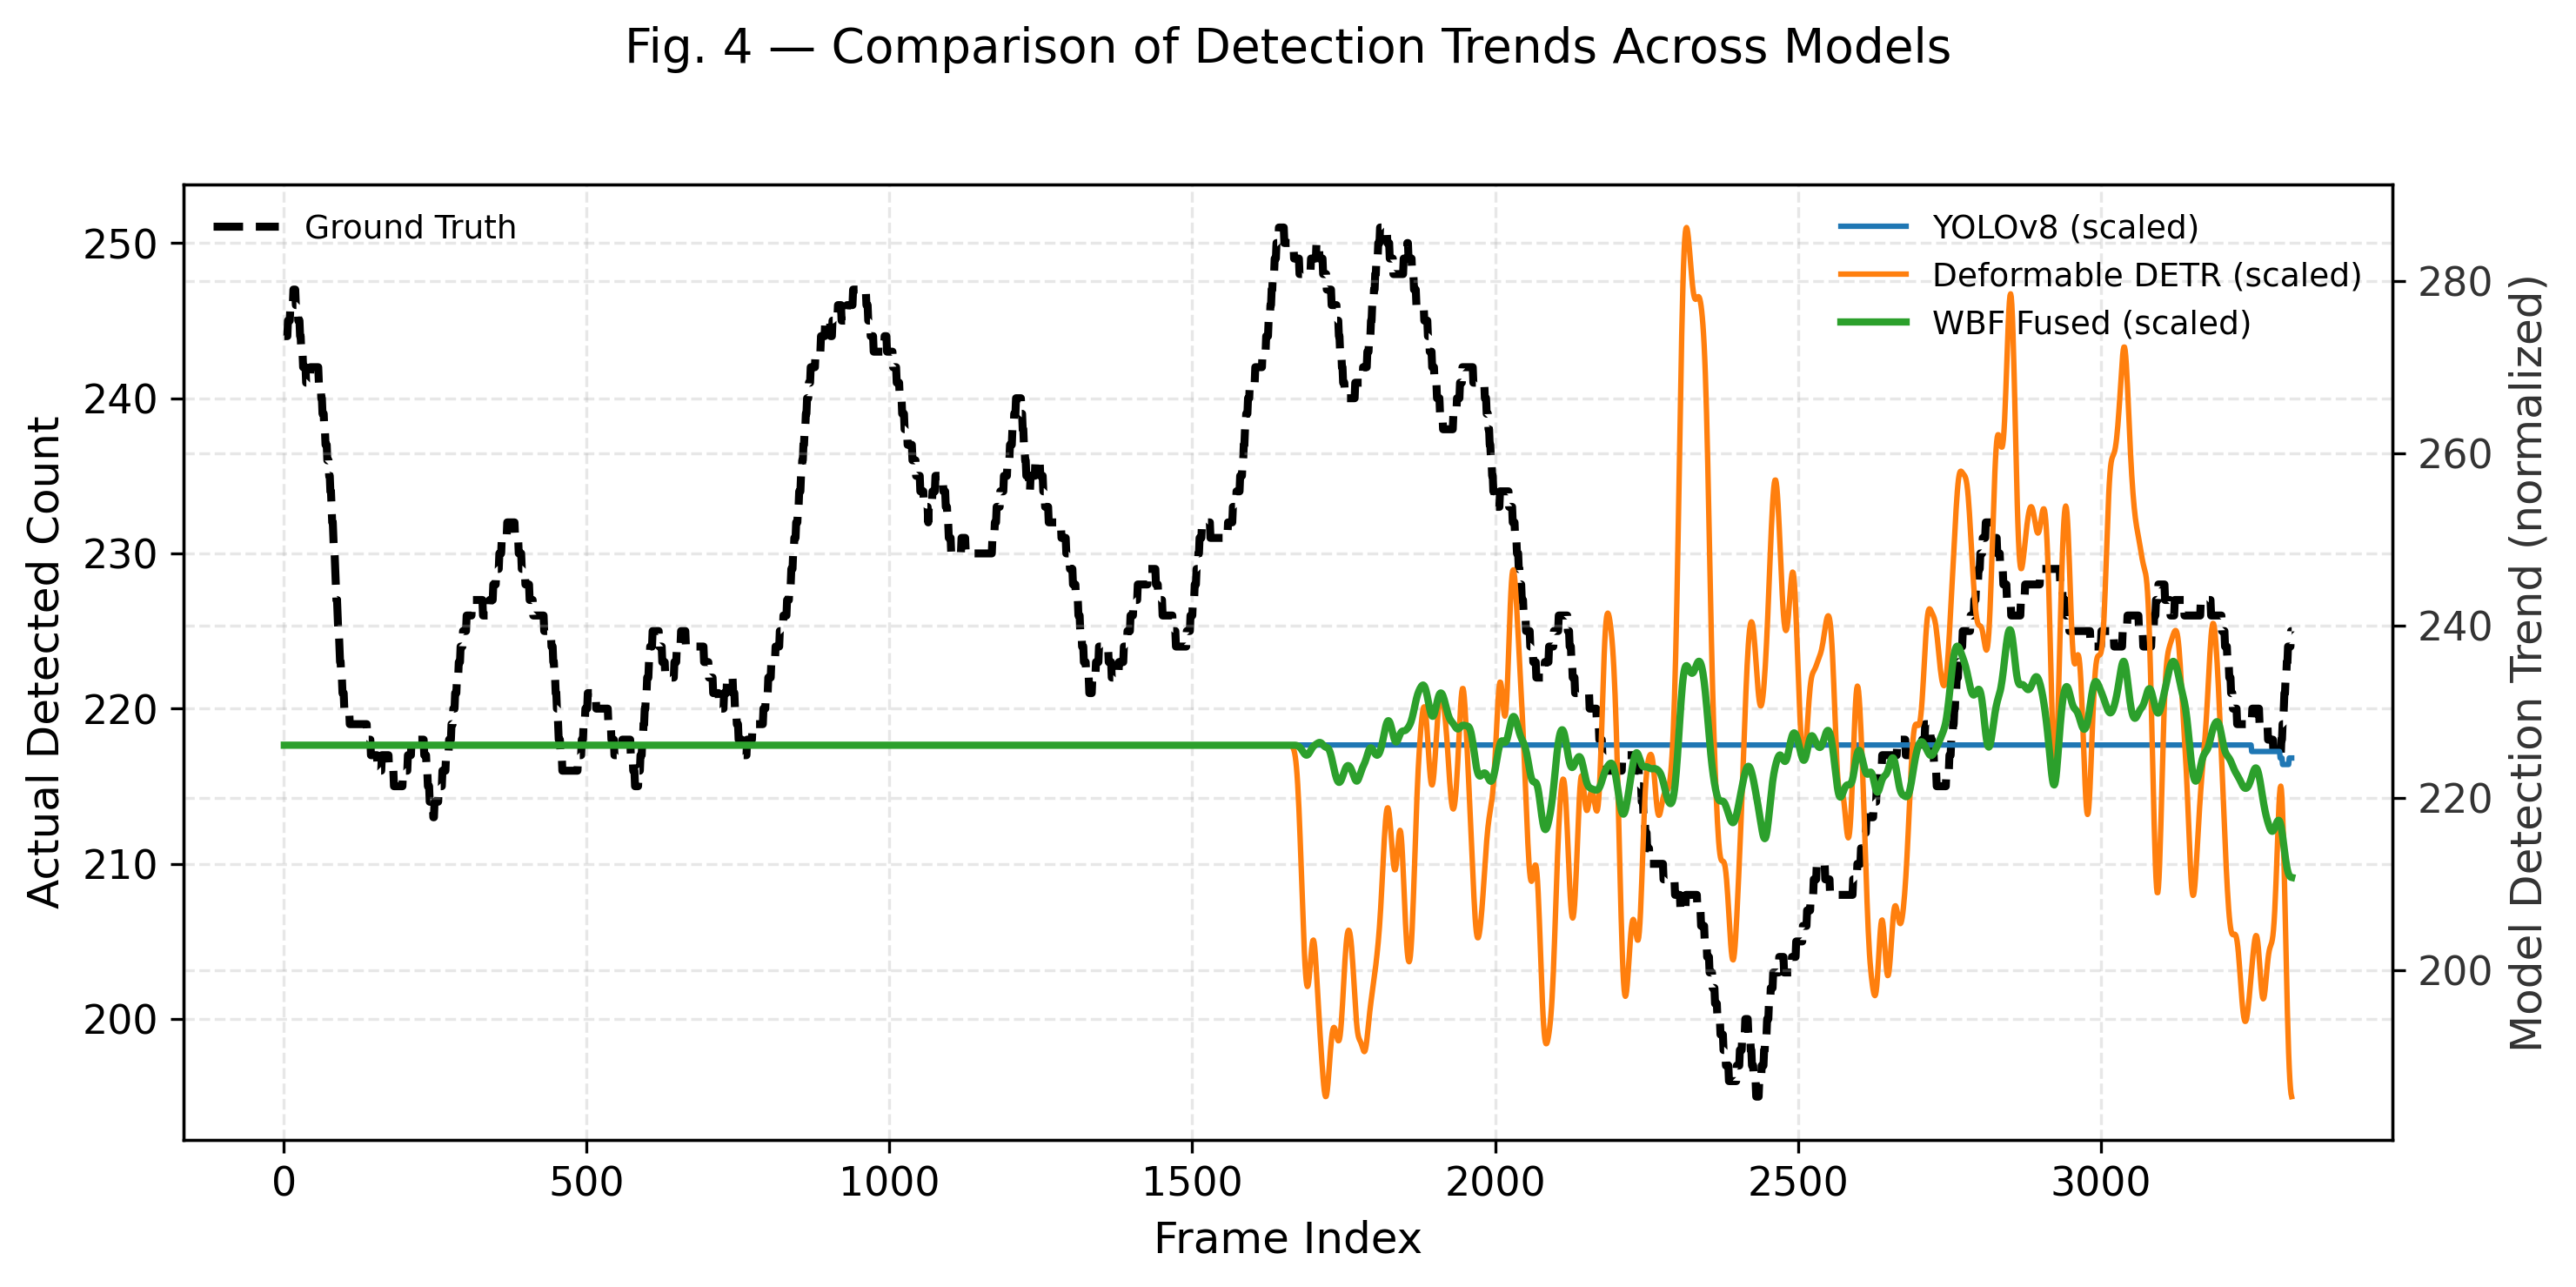

In [3]:
import matplotlib.pyplot as plt
import json, numpy as np, pandas as pd, os, re
from scipy.ndimage import gaussian_filter1d
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": False,
    "figure.dpi": 300
})

# --- Paths ---
YOLO_PATH = "/content/drive/MyDrive/Store/L1model/yolo_dets"
DETR_PATH = "/content/drive/MyDrive/Store/L1model/deform_detr_dets2/MOT20-05"
WBF_PATH  = "/content/drive/MyDrive/Store/L1model/deform_detr_dets_wbf2/MOT20-05"
GT_PATH   = "/content/drive/MyDrive/Store/MOT20/train/MOT20-05/gt/gt.txt"

def extract_id(fname):
    m = re.search(r'(\d+)', fname)
    return int(m.group(1)) if m else None

frame_files = sorted([f for f in os.listdir(YOLO_PATH) if f.endswith(".json")])
frame_ids = [extract_id(f) for f in frame_files if extract_id(f)]
frame_ids.sort()

counts_yolo, counts_detr, counts_wbf, counts_gt = [], [], [], []

for fid in frame_ids:
    yolo_file = f"{YOLO_PATH}/val_{fid:06d}.json" if os.path.exists(f"{YOLO_PATH}/val_{fid:06d}.json") else f"{YOLO_PATH}/{fid:06d}.json"
    detr_file = f"{DETR_PATH}/val_{fid:06d}.json" if os.path.exists(f"{DETR_PATH}/val_{fid:06d}.json") else f"{DETR_PATH}/{fid:06d}.json"
    wbf_file  = f"{WBF_PATH}/{fid:06d}.json"

    yolo_dets = json.load(open(yolo_file)) if os.path.exists(yolo_file) else []
    detr_dets = json.load(open(detr_file)) if os.path.exists(detr_file) else []
    wbf_dets  = json.load(open(wbf_file))  if os.path.exists(wbf_file)  else []

    counts_yolo.append(len(yolo_dets) or np.nan)
    counts_detr.append(len(detr_dets) or np.nan)
    counts_wbf.append(len(wbf_dets)  or np.nan)

# --- Ground truth ---
gt_df = pd.read_csv(GT_PATH, header=None)
for fid in frame_ids:
    counts_gt.append(len(gt_df[gt_df[0] == fid]) or np.nan)

# --- Smooth ---
smooth = lambda arr: gaussian_filter1d(np.nan_to_num(arr, nan=np.nanmean(arr)), sigma=6)
counts_gt_s, counts_yolo_s, counts_detr_s, counts_wbf_s = map(smooth, [counts_gt, counts_yolo, counts_detr, counts_wbf])

# --- Match length (cut to valid overlapping range) ---
mask = ~np.isnan(counts_wbf_s)
frame_ids = np.array(frame_ids)[mask]
counts_gt_s, counts_yolo_s, counts_detr_s, counts_wbf_s = [np.array(a)[mask] for a in [counts_gt_s, counts_yolo_s, counts_detr_s, counts_wbf_s]]

# --- Scale model predictions to similar range ---
mean_gt = np.nanmean(counts_gt_s)
scale = lambda arr: arr * (mean_gt / np.nanmean(arr))
counts_yolo_n, counts_detr_n, counts_wbf_n = map(scale, [counts_yolo_s, counts_detr_s, counts_wbf_s])

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax2 = ax1.twinx()

# Left axis: ground truth (true scale)
ax1.plot(frame_ids, counts_gt_s, '--', color='black', linewidth=2.2, label='Ground Truth')
ax1.set_ylabel("Actual Detected Count", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Right axis: models (normalized to GT scale)
ax2.plot(frame_ids, counts_yolo_n, color='#1f77b4', linewidth=1.5, label='YOLOv8 (scaled)')
ax2.plot(frame_ids, counts_detr_n, color='#ff7f0e', linewidth=1.5, label='Deformable DETR (scaled)')
ax2.plot(frame_ids, counts_wbf_n, color='#2ca02c', linewidth=2, label='WBF Fused (scaled)')
ax2.set_ylabel("Model Detection Trend (normalized)", color='#333333')
ax2.tick_params(axis='y', labelcolor='#333333')

# Titles and legend
fig.suptitle("Fig. 4 — Comparison of Detection Trends Across Models", y=1.02)
ax1.legend(loc="upper left", fontsize=9)
ax2.legend(loc="upper right", fontsize=9)
ax1.set_xlabel("Frame Index")

plt.tight_layout()
plt.show()


In [3]:
import numpy as np, matplotlib.pyplot as plt

npz = np.load("/content/L2Heuristic_labels/sequence_labeled.npz")
features, labels = npz["features"], npz["labels"]
# Suppose you’ve saved predicted LSTM probabilities:
probs = np.load("/content/L2Results/layer2_probs.npy")  # output from inference

plt.figure(figsize=(10,5))
plt.plot(probs, label="Predicted Risk Probability (LSTM)", color="orange")
plt.plot(labels, label="Heuristic Baseline (0=Safe, 1=Risk)", color="green", alpha=0.6)
plt.axhline(0.5, color='r', linestyle='--', label='Risk Threshold (0.5)')
plt.xlabel("Window Index")
plt.ylabel("Risk Probability")
plt.title("Fig. 5. Comparison of LSTM Risk Predictions vs Heuristic Labels")
plt.legend(); plt.tight_layout(); plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/L2Heuristic_labels/sequence_labeled.npz'

In [4]:
import pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/layer3_full_output.csv")
plt.figure(figsize=(10,4))
plt.scatter(df.index, df["pred_flag"], color='red', s=20, label='Predicted Risk (GCN)')
plt.scatter(df.index, df["risk_flag"], color='gray', s=15, alpha=0.5, label='True Risk (Heuristic)')
plt.xlabel("Window Index")
plt.ylabel("Risk Flag (0/1)")
plt.title("Fig. 6. Comparison of GCN Predicted vs Actual Risk Labels")
plt.legend(); plt.tight_layout(); plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/layer3_full_output.csv'